In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mlt
import seaborn as sb

## users_data datast data cleaning and data modeling

In [2]:
df1=pd.read_csv('users_data.csv')
df1

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,986,32,70,1987,7,Male,6577 Lexington Lane,40.65,-73.58,$23550,$48010,$87837,703,3
1996,1944,62,65,1957,11,Female,2 Elm Drive,38.95,-84.54,$24218,$49378,$104480,740,4
1997,185,47,67,1973,1,Female,276 Fifth Boulevard,40.66,-74.19,$15175,$30942,$71066,779,3
1998,1007,66,60,1954,2,Male,259 Valley Boulevard,40.24,-76.92,$25336,$54654,$27241,618,1


In [3]:
df1=df1.rename(columns={'id':'client_id'})

In [4]:
# as we only need few columns to solve business problem
df1=df1.drop(['birth_year','birth_month','address','latitude','longitude'],axis=1)
df1

,client_id,current_age,retirement_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,Female,$29278,$59696,$127613,787,5
1,1746,53,68,Female,$37891,$77254,$191349,701,5
2,1718,81,67,Female,$22681,$33483,$196,698,5
3,708,63,63,Female,$163145,$249925,$202328,722,4
4,1164,43,70,Male,$53797,$109687,$183855,675,1
...,...,...,...,...,...,...,...,...,...
1995,986,32,70,Male,$23550,$48010,$87837,703,3
1996,1944,62,65,Female,$24218,$49378,$104480,740,4
1997,185,47,67,Female,$15175,$30942,$71066,779,3
1998,1007,66,60,Male,$25336,$54654,$27241,618,1


In [5]:
df1.info

<bound method DataFrame.info of       client_id  current_age  retirement_age  gender per_capita_income  \
0           825           53              66  Female            $29278   
1          1746           53              68  Female            $37891   
2          1718           81              67  Female            $22681   
3           708           63              63  Female           $163145   
4          1164           43              70    Male            $53797   
...         ...          ...             ...     ...               ...   
1995        986           32              70    Male            $23550   
1996       1944           62              65  Female            $24218   
1997        185           47              67  Female            $15175   
1998       1007           66              60    Male            $25336   
1999       1110           21              60  Female            $32325   

     yearly_income total_debt  credit_score  num_credit_cards  
0           $59

In [6]:
df1.sort_values(by='client_id',ascending=True)

,client_id,current_age,retirement_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
958,0,33,69,Male,$29237,$59613,$36199,763,4
1298,1,43,74,Female,$22247,$45360,$14587,704,3
1876,2,48,64,Male,$13461,$27447,$80850,673,5
758,3,49,65,Male,$13705,$27943,$18693,681,4
424,4,54,72,Female,$37485,$76431,$115362,716,5
...,...,...,...,...,...,...,...,...,...
996,1995,64,62,Female,$20943,$39206,$9219,605,4
1361,1996,46,66,Female,$21956,$44768,$59862,728,3
365,1997,76,69,Male,$39155,$38800,$25867,758,7
1426,1998,65,67,Male,$0,$645,$790,688,3


In [7]:
df1.describe()

,client_id,current_age,retirement_age,credit_score,num_credit_cards
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,999.500000,45.391500,66.237500,709.734500,3.073000
std,577.494589,18.414092,3.628867,67.221949,1.637379
min,0.000000,18.000000,50.000000,480.000000,1.000000
25%,499.750000,30.000000,65.000000,681.000000,2.000000
50%,999.500000,44.000000,66.000000,711.500000,3.000000
75%,1499.250000,58.000000,68.000000,753.000000,4.000000
max,1999.000000,101.000000,79.000000,850.000000,9.000000


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   client_id          2000 non-null   int64 
 1   current_age        2000 non-null   int64 
 2   retirement_age     2000 non-null   int64 
 3   gender             2000 non-null   object
 4   per_capita_income  2000 non-null   object
 5   yearly_income      2000 non-null   object
 6   total_debt         2000 non-null   object
 7   credit_score       2000 non-null   int64 
 8   num_credit_cards   2000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 140.8+ KB


In [9]:
# deleting the $ sign and making the columns integer
df1['per_capita_income']=df1['per_capita_income'].str.replace('$','')
df1['yearly_income']=df1['yearly_income'].str.replace('$','')
df1['total_debt']=df1['total_debt'].str.replace('$','')
df1

,client_id,current_age,retirement_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,Female,29278,59696,127613,787,5
1,1746,53,68,Female,37891,77254,191349,701,5
2,1718,81,67,Female,22681,33483,196,698,5
3,708,63,63,Female,163145,249925,202328,722,4
4,1164,43,70,Male,53797,109687,183855,675,1
...,...,...,...,...,...,...,...,...,...
1995,986,32,70,Male,23550,48010,87837,703,3
1996,1944,62,65,Female,24218,49378,104480,740,4
1997,185,47,67,Female,15175,30942,71066,779,3
1998,1007,66,60,Male,25336,54654,27241,618,1


In [10]:
df1['per_capita_income']=df1['per_capita_income'].astype(int)
df1['yearly_income']=df1['yearly_income'].astype(int)
df1['total_debt']=df1['total_debt'].astype(int)
df1

,client_id,current_age,retirement_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,Female,29278,59696,127613,787,5
1,1746,53,68,Female,37891,77254,191349,701,5
2,1718,81,67,Female,22681,33483,196,698,5
3,708,63,63,Female,163145,249925,202328,722,4
4,1164,43,70,Male,53797,109687,183855,675,1
...,...,...,...,...,...,...,...,...,...
1995,986,32,70,Male,23550,48010,87837,703,3
1996,1944,62,65,Female,24218,49378,104480,740,4
1997,185,47,67,Female,15175,30942,71066,779,3
1998,1007,66,60,Male,25336,54654,27241,618,1


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   client_id          2000 non-null   int64 
 1   current_age        2000 non-null   int64 
 2   retirement_age     2000 non-null   int64 
 3   gender             2000 non-null   object
 4   per_capita_income  2000 non-null   int64 
 5   yearly_income      2000 non-null   int64 
 6   total_debt         2000 non-null   int64 
 7   credit_score       2000 non-null   int64 
 8   num_credit_cards   2000 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 140.8+ KB


In [12]:
# craeting new age_group column
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df1['age_group'] = pd.qcut(df1['current_age'], q=4, labels = labels)
df1

,client_id,current_age,retirement_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,age_group
0,825,53,66,Female,29278,59696,127613,787,5,Middle-aged
1,1746,53,68,Female,37891,77254,191349,701,5,Middle-aged
2,1718,81,67,Female,22681,33483,196,698,5,Senior
3,708,63,63,Female,163145,249925,202328,722,4,Senior
4,1164,43,70,Male,53797,109687,183855,675,1,Adult
...,...,...,...,...,...,...,...,...,...,...
1995,986,32,70,Male,23550,48010,87837,703,3,Adult
1996,1944,62,65,Female,24218,49378,104480,740,4,Senior
1997,185,47,67,Female,15175,30942,71066,779,3,Middle-aged
1998,1007,66,60,Male,25336,54654,27241,618,1,Senior


## Dataset Exploratory data analysis

<Axes: xlabel='gender'>

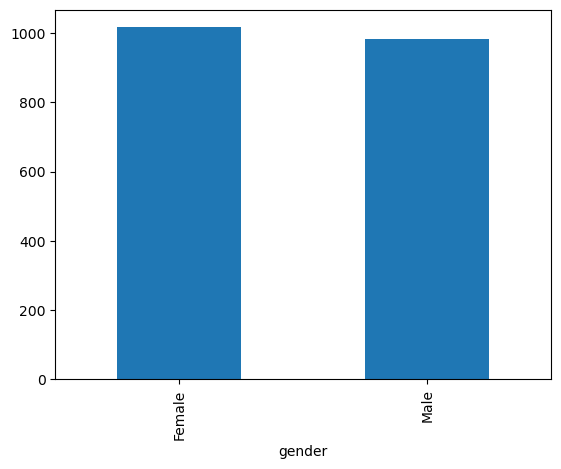

In [13]:

df1.groupby('gender')['client_id'].count().plot(kind='bar')

<Axes: xlabel='gender'>

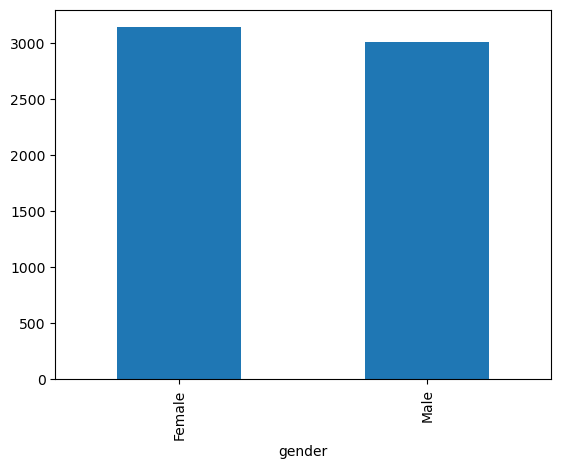

In [14]:
df1.groupby('gender')['num_credit_cards'].sum().plot(kind='bar')

<Axes: xlabel='gender'>

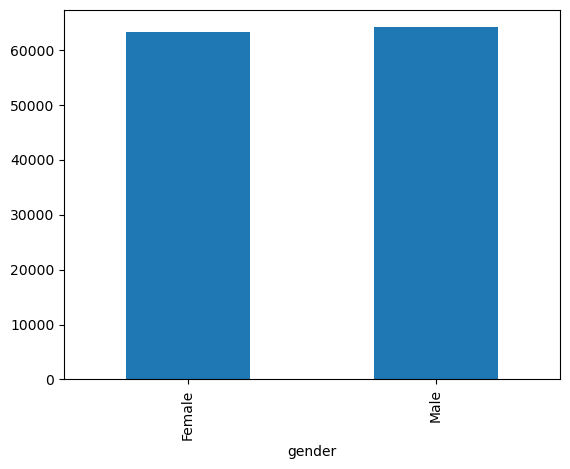

In [15]:
df1.groupby('gender')['total_debt'].mean().plot(kind='bar')

<Axes: xlabel='gender'>

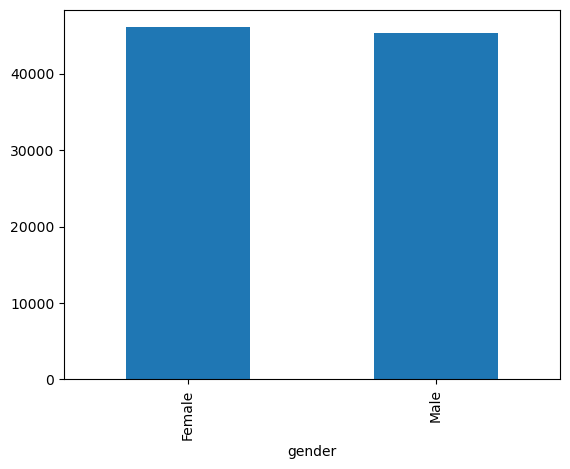

In [16]:
df1.groupby('gender')['yearly_income'].mean().plot(kind='bar')

<Axes: xlabel='age_group', ylabel='count'>

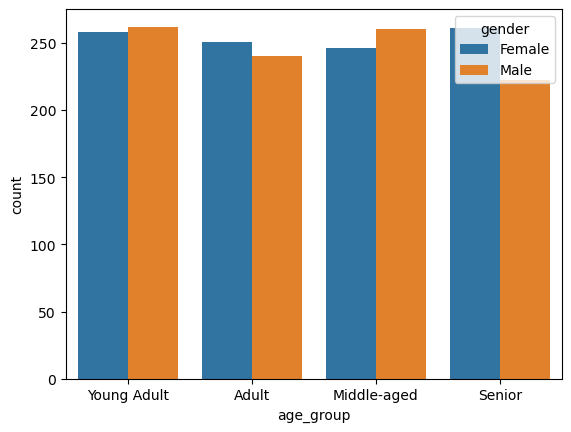

In [17]:
sb.countplot(x='age_group',data=df1, hue='gender')

<Axes: xlabel='num_credit_cards', ylabel='count'>

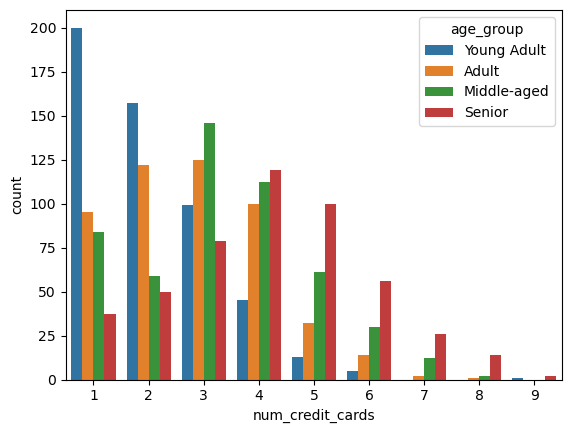

In [18]:
sb.countplot(x='num_credit_cards',data=df1, hue='age_group')

## card_data dataset data cleaning and data modeling

In [19]:
df2=pd.read_csv('cards_data.csv')
df2

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,2711,185,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


In [20]:
df2=df2.rename(columns={'id':'card_id'})

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   card_id                6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [22]:
df2=df2.drop(['card_number','expires','num_cards_issued','cvv','year_pin_last_changed'],axis=1)

In [23]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   card_id           6146 non-null   int64 
 1   client_id         6146 non-null   int64 
 2   card_brand        6146 non-null   object
 3   card_type         6146 non-null   object
 4   has_chip          6146 non-null   object
 5   credit_limit      6146 non-null   object
 6   acct_open_date    6146 non-null   object
 7   card_on_dark_web  6146 non-null   object
dtypes: int64(2), object(6)
memory usage: 384.3+ KB


In [24]:
from datetime import datetime 
df2['acct_open_date']=pd.to_datetime(df2['acct_open_date'],format='%m/%Y')
df2['acct_open_date']=df2['acct_open_date'].dt.strftime('%m/%Y')
df2

,card_id,client_id,card_brand,card_type,has_chip,credit_limit,acct_open_date,card_on_dark_web
0,4524,825,Visa,Debit,YES,$24295,09/2002,No
1,2731,825,Visa,Debit,YES,$21968,04/2014,No
2,3701,825,Visa,Debit,YES,$46414,07/2003,No
3,42,825,Visa,Credit,NO,$12400,01/2003,No
4,4659,825,Mastercard,Debit (Prepaid),YES,$28,09/2008,No
...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,YES,$6900,11/2000,No
6142,2711,185,Visa,Credit,YES,$5700,04/2012,No
6143,1305,1007,Mastercard,Credit,NO,$9200,02/2012,No
6144,743,1110,Mastercard,Debit,YES,$28074,01/2020,No


In [25]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   card_id           6146 non-null   int64 
 1   client_id         6146 non-null   int64 
 2   card_brand        6146 non-null   object
 3   card_type         6146 non-null   object
 4   has_chip          6146 non-null   object
 5   credit_limit      6146 non-null   object
 6   acct_open_date    6146 non-null   object
 7   card_on_dark_web  6146 non-null   object
dtypes: int64(2), object(6)
memory usage: 384.3+ KB


In [26]:
#making the credit limit column integer by removing $
df2['credit_limit']=df2['credit_limit'].str.replace('$','')
df2['credit_limit']=df2['credit_limit'].astype(int)
df2

,card_id,client_id,card_brand,card_type,has_chip,credit_limit,acct_open_date,card_on_dark_web
0,4524,825,Visa,Debit,YES,24295,09/2002,No
1,2731,825,Visa,Debit,YES,21968,04/2014,No
2,3701,825,Visa,Debit,YES,46414,07/2003,No
3,42,825,Visa,Credit,NO,12400,01/2003,No
4,4659,825,Mastercard,Debit (Prepaid),YES,28,09/2008,No
...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,YES,6900,11/2000,No
6142,2711,185,Visa,Credit,YES,5700,04/2012,No
6143,1305,1007,Mastercard,Credit,NO,9200,02/2012,No
6144,743,1110,Mastercard,Debit,YES,28074,01/2020,No


In [27]:
# no cards has is listed on dark web
df2.groupby('card_on_dark_web').count()

,card_id,client_id,card_brand,card_type,has_chip,credit_limit,acct_open_date
card_on_dark_web,,,,,,,
No,6146,6146,6146,6146,6146,6146,6146


In [28]:
# deleting the card_on_dark_web column
df2=df2.drop(['card_on_dark_web'],axis=1)
df2

,card_id,client_id,card_brand,card_type,has_chip,credit_limit,acct_open_date
0,4524,825,Visa,Debit,YES,24295,09/2002
1,2731,825,Visa,Debit,YES,21968,04/2014
2,3701,825,Visa,Debit,YES,46414,07/2003
3,42,825,Visa,Credit,NO,12400,01/2003
4,4659,825,Mastercard,Debit (Prepaid),YES,28,09/2008
...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,YES,6900,11/2000
6142,2711,185,Visa,Credit,YES,5700,04/2012
6143,1305,1007,Mastercard,Credit,NO,9200,02/2012
6144,743,1110,Mastercard,Debit,YES,28074,01/2020


In [29]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   card_id         6146 non-null   int64 
 1   client_id       6146 non-null   int64 
 2   card_brand      6146 non-null   object
 3   card_type       6146 non-null   object
 4   has_chip        6146 non-null   object
 5   credit_limit    6146 non-null   int64 
 6   acct_open_date  6146 non-null   object
dtypes: int64(3), object(4)
memory usage: 336.2+ KB


## dataset Exploratory data analysis 

In [30]:
df2.describe()

,card_id,client_id,credit_limit
count,6146.000000,6146.000000,6146.000000
mean,3072.500000,994.939636,14347.493980
std,1774.341709,578.614626,12014.463884
min,0.000000,0.000000,0.000000
25%,1536.250000,492.250000,7042.750000
50%,3072.500000,992.000000,12592.500000
75%,4608.750000,1495.000000,19156.500000
max,6145.000000,1999.000000,151223.000000


In [31]:
df2['client_id'].nunique()

2000

In [32]:
df2.groupby('card_brand').count()

,card_id,client_id,card_type,has_chip,credit_limit,acct_open_date
card_brand,,,,,,
Amex,402,402,402,402,402,402
Discover,209,209,209,209,209,209
Mastercard,3209,3209,3209,3209,3209,3209
Visa,2326,2326,2326,2326,2326,2326


In [33]:
df2.groupby('card_type').count()

,card_id,client_id,card_brand,has_chip,credit_limit,acct_open_date
card_type,,,,,,
Credit,2057,2057,2057,2057,2057,2057
Debit,3511,3511,3511,3511,3511,3511
Debit (Prepaid),578,578,578,578,578,578


<Axes: xlabel='card_brand', ylabel='count'>

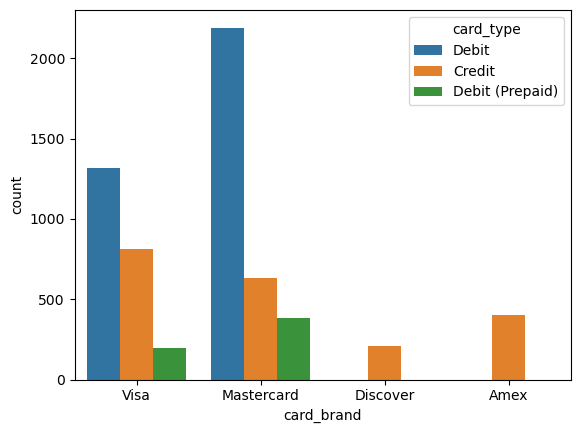

In [34]:
sb.countplot(x='card_brand',data=df2, hue='card_type')

<Axes: xlabel='card_type', ylabel='count'>

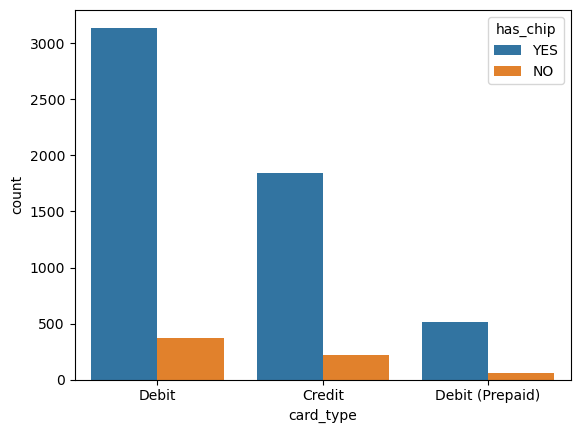

In [35]:
sb.countplot(x='card_type',data=df2, hue='has_chip')

<Axes: xlabel='card_brand', ylabel='count'>

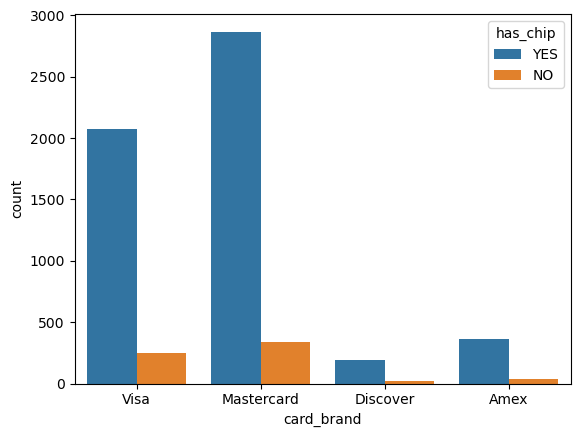

In [36]:
sb.countplot(x='card_brand',data=df2, hue='has_chip')

In [37]:
print(df2.groupby(['card_brand','card_type'])['credit_limit'].min())

card_brand  card_type      
Amex        Credit             0
Discover    Credit             0
Mastercard  Credit             0
            Debit              0
            Debit (Prepaid)    0
Visa        Credit             0
            Debit              1
            Debit (Prepaid)    0
Name: credit_limit, dtype: int64


In [38]:
print(df2.groupby(['card_brand','card_type'])['credit_limit'].max())

card_brand  card_type      
Amex        Credit              89900
Discover    Credit              44200
Mastercard  Credit              55300
            Debit              151223
            Debit (Prepaid)       130
Visa        Credit              98100
            Debit              132439
            Debit (Prepaid)       145
Name: credit_limit, dtype: int64


## transaction_data dataset data cleaning and data modeling

In [39]:
df3=pd.read_csv('transaction_data.csv')
df3

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,01-01-2010 00:01,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475334,01-01-2010 00:09,1556,2972,$77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
2,7475340,01-01-2010 00:26,1556,2972,$39.63,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
3,7475346,01-01-2010 00:34,394,4717,$26.04,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
4,7475353,01-01-2010 00:43,301,3742,$10.17,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
44995,7815736,28-03-2010 07:13,1020,1224,$4.85,Swipe Transaction,17493,Schaumburg,IL,60194.0,5812,NaN
44996,7815744,28-03-2010 07:14,1595,2429,$6.11,Swipe Transaction,50783,Bronx,NY,10466.0,5411,NaN
44997,7815752,28-03-2010 07:17,847,5107,$50.65,Swipe Transaction,32175,Alsip,IL,60803.0,7538,NaN
44998,7815760,28-03-2010 07:18,1424,4710,$-83.00,Swipe Transaction,59935,Kingman,AZ,86401.0,5499,NaN


In [40]:
df3=df3.rename(columns={'id':'transaction_id'})

In [41]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  45000 non-null  int64  
 1   date            45000 non-null  object 
 2   client_id       45000 non-null  int64  
 3   card_id         45000 non-null  int64  
 4   amount          45000 non-null  object 
 5   use_chip        45000 non-null  object 
 6   merchant_id     45000 non-null  int64  
 7   merchant_city   45000 non-null  object 
 8   merchant_state  39991 non-null  object 
 9   zip             39765 non-null  float64
 10  mcc             45000 non-null  int64  
 11  errors          674 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 4.1+ MB


In [42]:
df3.isnull().sum()

transaction_id        0
date                  0
client_id             0
card_id               0
amount                0
use_chip              0
merchant_id           0
merchant_city         0
merchant_state     5009
zip                5235
mcc                   0
errors            44326
dtype: int64

In [43]:
# deleting unecessary columns
df3=df3.drop(['merchant_id'],axis=1)
df3

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_city,merchant_state,zip,mcc,errors
0,7475327,01-01-2010 00:01,1556,2972,$-77.00,Swipe Transaction,Beulah,ND,58523.0,5499,NaN
1,7475334,01-01-2010 00:09,1556,2972,$77.00,Swipe Transaction,Beulah,ND,58523.0,5499,NaN
2,7475340,01-01-2010 00:26,1556,2972,$39.63,Swipe Transaction,Beulah,ND,58523.0,5499,NaN
3,7475346,01-01-2010 00:34,394,4717,$26.04,Online Transaction,ONLINE,NaN,NaN,4784,NaN
4,7475353,01-01-2010 00:43,301,3742,$10.17,Online Transaction,ONLINE,NaN,NaN,4784,NaN
...,...,...,...,...,...,...,...,...,...,...,...
44995,7815736,28-03-2010 07:13,1020,1224,$4.85,Swipe Transaction,Schaumburg,IL,60194.0,5812,NaN
44996,7815744,28-03-2010 07:14,1595,2429,$6.11,Swipe Transaction,Bronx,NY,10466.0,5411,NaN
44997,7815752,28-03-2010 07:17,847,5107,$50.65,Swipe Transaction,Alsip,IL,60803.0,7538,NaN
44998,7815760,28-03-2010 07:18,1424,4710,$-83.00,Swipe Transaction,Kingman,AZ,86401.0,5499,NaN


In [44]:
df3['errors']=df3['errors'].fillna('Unknown')
df3

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_city,merchant_state,zip,mcc,errors
0,7475327,01-01-2010 00:01,1556,2972,$-77.00,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
1,7475334,01-01-2010 00:09,1556,2972,$77.00,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
2,7475340,01-01-2010 00:26,1556,2972,$39.63,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
3,7475346,01-01-2010 00:34,394,4717,$26.04,Online Transaction,ONLINE,NaN,NaN,4784,Unknown
4,7475353,01-01-2010 00:43,301,3742,$10.17,Online Transaction,ONLINE,NaN,NaN,4784,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
44995,7815736,28-03-2010 07:13,1020,1224,$4.85,Swipe Transaction,Schaumburg,IL,60194.0,5812,Unknown
44996,7815744,28-03-2010 07:14,1595,2429,$6.11,Swipe Transaction,Bronx,NY,10466.0,5411,Unknown
44997,7815752,28-03-2010 07:17,847,5107,$50.65,Swipe Transaction,Alsip,IL,60803.0,7538,Unknown
44998,7815760,28-03-2010 07:18,1424,4710,$-83.00,Swipe Transaction,Kingman,AZ,86401.0,5499,Unknown


In [45]:
df3.isnull().sum()

transaction_id       0
date                 0
client_id            0
card_id              0
amount               0
use_chip             0
merchant_city        0
merchant_state    5009
zip               5235
mcc                  0
errors               0
dtype: int64

In [46]:
#we have null values in merchant_state and zip column. Lets try to impute it with merchant_city column
a=df3[df3['merchant_state'].isnull()]
print(a)
print('*'*50)
#looks like we have merchant_city col with only Online value in it
print(a['merchant_city'].nunique())
print("*"*50)
# deleting the rows with none value is best option we have
df3=df3.dropna(axis=0)
df3

       transaction_id              date  client_id  card_id  amount  \
3             7475346  01-01-2010 00:34        394     4717  $26.04   
4             7475353  01-01-2010 00:43        301     3742  $10.17   
11            7475403  01-01-2010 01:56        760     5876  $52.98   
14            7475425  01-01-2010 02:16        241       58  $38.11   
15            7475432  01-01-2010 02:25       1214     5508  $51.58   
...               ...               ...        ...      ...     ...   
44926         7815254  28-03-2010 01:26       1575     5582  $30.56   
44940         7815351  28-03-2010 04:38       1718     4706  $42.14   
44945         7815383  28-03-2010 05:22        708     5165  $90.26   
44954         7815443  28-03-2010 06:05       1190     5358  $35.97   
44999         7815767  28-03-2010 07:20       1269     4147  $30.13   

                 use_chip merchant_city merchant_state  zip   mcc   errors  
3      Online Transaction        ONLINE            NaN  NaN  4784  Unk

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_city,merchant_state,zip,mcc,errors
0,7475327,01-01-2010 00:01,1556,2972,$-77.00,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
1,7475334,01-01-2010 00:09,1556,2972,$77.00,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
2,7475340,01-01-2010 00:26,1556,2972,$39.63,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
5,7475360,01-01-2010 00:49,652,4293,$2.40,Swipe Transaction,East Hartford,CT,6108.0,5411,Unknown
6,7475366,01-01-2010 01:03,1703,2969,$78.00,Swipe Transaction,Grand Junction,CO,81506.0,5499,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
44994,7815729,28-03-2010 07:12,552,3275,$45.56,Swipe Transaction,Gainesville,FL,32608.0,5541,Unknown
44995,7815736,28-03-2010 07:13,1020,1224,$4.85,Swipe Transaction,Schaumburg,IL,60194.0,5812,Unknown
44996,7815744,28-03-2010 07:14,1595,2429,$6.11,Swipe Transaction,Bronx,NY,10466.0,5411,Unknown
44997,7815752,28-03-2010 07:17,847,5107,$50.65,Swipe Transaction,Alsip,IL,60803.0,7538,Unknown


In [47]:
df3.isnull().sum()

transaction_id    0
date              0
client_id         0
card_id           0
amount            0
use_chip          0
merchant_city     0
merchant_state    0
zip               0
mcc               0
errors            0
dtype: int64

In [48]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39765 entries, 0 to 44998
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  39765 non-null  int64  
 1   date            39765 non-null  object 
 2   client_id       39765 non-null  int64  
 3   card_id         39765 non-null  int64  
 4   amount          39765 non-null  object 
 5   use_chip        39765 non-null  object 
 6   merchant_city   39765 non-null  object 
 7   merchant_state  39765 non-null  object 
 8   zip             39765 non-null  float64
 9   mcc             39765 non-null  int64  
 10  errors          39765 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 3.6+ MB


In [49]:
from datetime import datetime
df3['date']=pd.to_datetime(df3['date'],format='%d-%m-%Y %H:%M')
df3

C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\1082848221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['date']=pd.to_datetime(df3['date'],format='%d-%m-%Y %H:%M')


,transaction_id,date,client_id,card_id,amount,use_chip,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
1,7475334,2010-01-01 00:09:00,1556,2972,$77.00,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
2,7475340,2010-01-01 00:26:00,1556,2972,$39.63,Swipe Transaction,Beulah,ND,58523.0,5499,Unknown
5,7475360,2010-01-01 00:49:00,652,4293,$2.40,Swipe Transaction,East Hartford,CT,6108.0,5411,Unknown
6,7475366,2010-01-01 01:03:00,1703,2969,$78.00,Swipe Transaction,Grand Junction,CO,81506.0,5499,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
44994,7815729,2010-03-28 07:12:00,552,3275,$45.56,Swipe Transaction,Gainesville,FL,32608.0,5541,Unknown
44995,7815736,2010-03-28 07:13:00,1020,1224,$4.85,Swipe Transaction,Schaumburg,IL,60194.0,5812,Unknown
44996,7815744,2010-03-28 07:14:00,1595,2429,$6.11,Swipe Transaction,Bronx,NY,10466.0,5411,Unknown
44997,7815752,2010-03-28 07:17:00,847,5107,$50.65,Swipe Transaction,Alsip,IL,60803.0,7538,Unknown


In [50]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39765 entries, 0 to 44998
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  39765 non-null  int64         
 1   date            39765 non-null  datetime64[ns]
 2   client_id       39765 non-null  int64         
 3   card_id         39765 non-null  int64         
 4   amount          39765 non-null  object        
 5   use_chip        39765 non-null  object        
 6   merchant_city   39765 non-null  object        
 7   merchant_state  39765 non-null  object        
 8   zip             39765 non-null  float64       
 9   mcc             39765 non-null  int64         
 10  errors          39765 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 3.6+ MB


In [51]:
#lets make zip columns as integer
df3['zip']=df3['zip'].astype('str')
df3['zip']=df3['zip'].str.replace('.0','')
df3['zip']=df3['zip'].astype(int)
df3

C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\896366754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['zip']=df3['zip'].astype('str')
C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\896366754.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['zip']=df3['zip'].str.replace('.0','')
C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\896366754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

,transaction_id,date,client_id,card_id,amount,use_chip,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,Beulah,ND,58523,5499,Unknown
1,7475334,2010-01-01 00:09:00,1556,2972,$77.00,Swipe Transaction,Beulah,ND,58523,5499,Unknown
2,7475340,2010-01-01 00:26:00,1556,2972,$39.63,Swipe Transaction,Beulah,ND,58523,5499,Unknown
5,7475360,2010-01-01 00:49:00,652,4293,$2.40,Swipe Transaction,East Hartford,CT,6108,5411,Unknown
6,7475366,2010-01-01 01:03:00,1703,2969,$78.00,Swipe Transaction,Grand Junction,CO,81506,5499,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
44994,7815729,2010-03-28 07:12:00,552,3275,$45.56,Swipe Transaction,Gainesville,FL,32608,5541,Unknown
44995,7815736,2010-03-28 07:13:00,1020,1224,$4.85,Swipe Transaction,Schaumburg,IL,60194,5812,Unknown
44996,7815744,2010-03-28 07:14:00,1595,2429,$6.11,Swipe Transaction,Bronx,NY,10466,5411,Unknown
44997,7815752,2010-03-28 07:17:00,847,5107,$50.65,Swipe Transaction,Alsip,IL,60803,7538,Unknown


In [52]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39765 entries, 0 to 44998
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  39765 non-null  int64         
 1   date            39765 non-null  datetime64[ns]
 2   client_id       39765 non-null  int64         
 3   card_id         39765 non-null  int64         
 4   amount          39765 non-null  object        
 5   use_chip        39765 non-null  object        
 6   merchant_city   39765 non-null  object        
 7   merchant_state  39765 non-null  object        
 8   zip             39765 non-null  int64         
 9   mcc             39765 non-null  int64         
 10  errors          39765 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(5)
memory usage: 3.6+ MB


In [53]:
# lets remove the dollar sign in amount columns and make the dtype as integer
df3['amount']=df3['amount'].str.replace('$','')
df3

C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\432841951.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['amount']=df3['amount'].str.replace('$','')


,transaction_id,date,client_id,card_id,amount,use_chip,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,Beulah,ND,58523,5499,Unknown
1,7475334,2010-01-01 00:09:00,1556,2972,77.00,Swipe Transaction,Beulah,ND,58523,5499,Unknown
2,7475340,2010-01-01 00:26:00,1556,2972,39.63,Swipe Transaction,Beulah,ND,58523,5499,Unknown
5,7475360,2010-01-01 00:49:00,652,4293,2.40,Swipe Transaction,East Hartford,CT,6108,5411,Unknown
6,7475366,2010-01-01 01:03:00,1703,2969,78.00,Swipe Transaction,Grand Junction,CO,81506,5499,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
44994,7815729,2010-03-28 07:12:00,552,3275,45.56,Swipe Transaction,Gainesville,FL,32608,5541,Unknown
44995,7815736,2010-03-28 07:13:00,1020,1224,4.85,Swipe Transaction,Schaumburg,IL,60194,5812,Unknown
44996,7815744,2010-03-28 07:14:00,1595,2429,6.11,Swipe Transaction,Bronx,NY,10466,5411,Unknown
44997,7815752,2010-03-28 07:17:00,847,5107,50.65,Swipe Transaction,Alsip,IL,60803,7538,Unknown


In [54]:
#lets make the negative values amount column as zero
df3['amount']=pd.to_numeric(df3['amount'],errors='coerce').clip(lower=0)
df3

C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\3385456150.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['amount']=pd.to_numeric(df3['amount'],errors='coerce').clip(lower=0)


,transaction_id,date,client_id,card_id,amount,use_chip,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,0.00,Swipe Transaction,Beulah,ND,58523,5499,Unknown
1,7475334,2010-01-01 00:09:00,1556,2972,77.00,Swipe Transaction,Beulah,ND,58523,5499,Unknown
2,7475340,2010-01-01 00:26:00,1556,2972,39.63,Swipe Transaction,Beulah,ND,58523,5499,Unknown
5,7475360,2010-01-01 00:49:00,652,4293,2.40,Swipe Transaction,East Hartford,CT,6108,5411,Unknown
6,7475366,2010-01-01 01:03:00,1703,2969,78.00,Swipe Transaction,Grand Junction,CO,81506,5499,Unknown
...,...,...,...,...,...,...,...,...,...,...,...
44994,7815729,2010-03-28 07:12:00,552,3275,45.56,Swipe Transaction,Gainesville,FL,32608,5541,Unknown
44995,7815736,2010-03-28 07:13:00,1020,1224,4.85,Swipe Transaction,Schaumburg,IL,60194,5812,Unknown
44996,7815744,2010-03-28 07:14:00,1595,2429,6.11,Swipe Transaction,Bronx,NY,10466,5411,Unknown
44997,7815752,2010-03-28 07:17:00,847,5107,50.65,Swipe Transaction,Alsip,IL,60803,7538,Unknown


In [55]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39765 entries, 0 to 44998
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  39765 non-null  int64         
 1   date            39765 non-null  datetime64[ns]
 2   client_id       39765 non-null  int64         
 3   card_id         39765 non-null  int64         
 4   amount          39765 non-null  float64       
 5   use_chip        39765 non-null  object        
 6   merchant_city   39765 non-null  object        
 7   merchant_state  39765 non-null  object        
 8   zip             39765 non-null  int64         
 9   mcc             39765 non-null  int64         
 10  errors          39765 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(4)
memory usage: 3.6+ MB


In [56]:
for i in df3.columns:
    print('column=',i)
    print(df3[i].unique())
    print(df3[i].nunique())
    print("*"*100)

column= transaction_id
[7475327 7475334 7475340 ... 7815744 7815752 7815760]
39765
****************************************************************************************************
column= date
<DatetimeArray>
['2010-01-01 00:01:00', '2010-01-01 00:09:00', '2010-01-01 00:26:00',
 '2010-01-01 00:49:00', '2010-01-01 01:03:00', '2010-01-01 01:11:00',
 '2010-01-01 01:23:00', '2010-01-01 01:40:00', '2010-01-01 01:48:00',
 '2010-01-01 02:06:00',
 ...
 '2010-03-28 07:04:00', '2010-03-28 07:06:00', '2010-03-28 07:08:00',
 '2010-03-28 07:09:00', '2010-03-28 07:11:00', '2010-03-28 07:12:00',
 '2010-03-28 07:13:00', '2010-03-28 07:14:00', '2010-03-28 07:17:00',
 '2010-03-28 07:18:00']
Length: 38776, dtype: datetime64[ns]
38776
****************************************************************************************************
column= client_id
[1556  652 1703 ...  949  524  220]
1096
****************************************************************************************************
column= ca

## Data exploratory analysis

In [57]:
df3.describe()

,transaction_id,date,client_id,card_id,amount,zip,mcc
count,3.976500e+04,39765,39765.000000,39765.000000,39765.00000,39765.000000,39765.000000
mean,7.647145e+06,2010-02-13 15:54:56.956620288,1022.796203,3389.545253,47.71093,51346.761373,5644.198868
min,7.475327e+06,2010-01-01 00:01:00,0.000000,0.000000,0.00000,1040.000000,1711.000000
25%,7.556057e+06,2010-01-21 14:49:00,506.000000,2216.000000,7.77000,28610.000000,5311.000000
50%,7.650195e+06,2010-02-14 12:48:00,1063.000000,3446.000000,28.38000,47501.000000,5499.000000
75%,7.735169e+06,2010-03-07 18:03:00,1528.000000,4754.000000,66.65000,78015.000000,5813.000000
max,7.815760e+06,2010-03-28 07:18:00,1998.000000,5990.000000,2507.17000,99829.000000,9402.000000
std,1.000891e+05,NaN,583.377741,1710.130251,71.89163,29485.240372,840.490299


month
February    637512.93
January     628586.59
March       631125.61
Name: amount, dtype: float64


C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\2337440831.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['month']=df3['date'].dt.month_name()


<Axes: xlabel='month'>

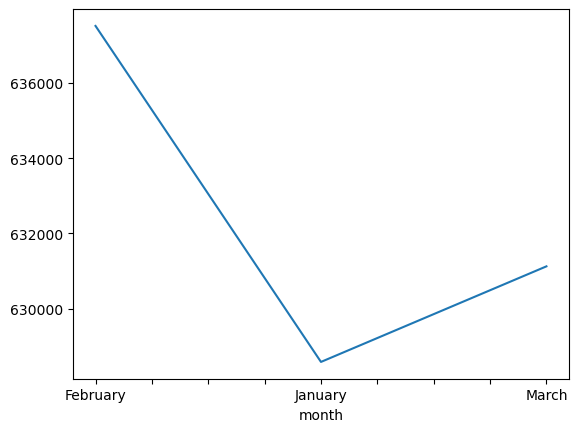

In [58]:
df3['month']=df3['date'].dt.month_name()
print(df3.groupby('month')['amount'].sum())
df3.groupby('month')['amount'].sum().plot(kind='line')

           day    amount
45  2010-02-18  28650.21
34  2010-02-07  27679.37
79  2010-03-25  27330.02
53  2010-02-26  27043.17
32  2010-02-05  26783.85
..         ...       ...
48  2010-02-21  19594.36
17  2010-01-18  19593.98
14  2010-01-15  19269.12
27  2010-01-28   9445.79
82  2010-03-28   2406.59

[83 rows x 2 columns]


C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\4130975532.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['day']=df3['date'].dt.date


<Axes: >

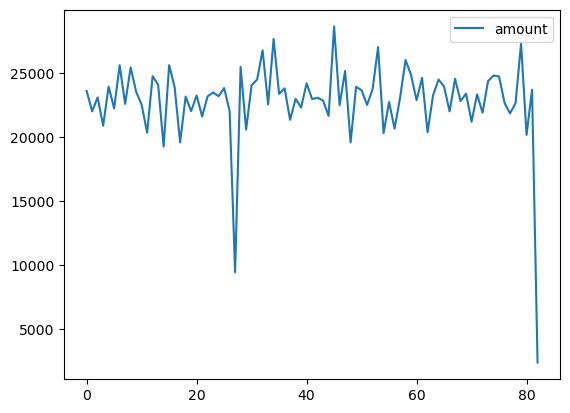

In [59]:
df3['day']=df3['date'].dt.date
a=df3.groupby('day')['amount'].sum().reset_index()
print(a.sort_values(by='amount',ascending=False))
# .sort_values(by='amount',ascending=False)
# print(a)
a.plot(kind='line')

merchant_state
CA    242259.89
TX    174637.88
NY    155491.15
FL    118563.66
IL     85026.29
PA     70139.96
OH     70040.28
NC     68700.42
MI     58676.34
NJ     58279.78
GA     51737.58
WA     50524.97
VA     49129.67
IN     47596.48
TN     43110.27
AZ     31312.78
MN     30935.28
CO     29943.86
MD     29707.78
WI     29601.96
MA     27762.71
CT     26580.32
LA     25168.20
SC     24372.17
AL     23758.34
OK     21848.53
KY     21405.28
MO     20804.52
IA     20112.39
NV     19961.79
HI     18790.45
NM     16093.75
OR     14418.27
MS     14347.86
KS     13705.66
AR     12139.71
RI     11949.78
NH      9556.86
NE      9547.24
ME      8106.02
ID      7385.79
WV      6424.76
ND      5227.10
AK      4305.43
UT      3596.22
SD      3390.87
VT      2932.18
DE      2255.49
DC      2154.49
MT      1986.71
WY      1719.96
Name: amount, dtype: float64


<Axes: xlabel='merchant_state'>

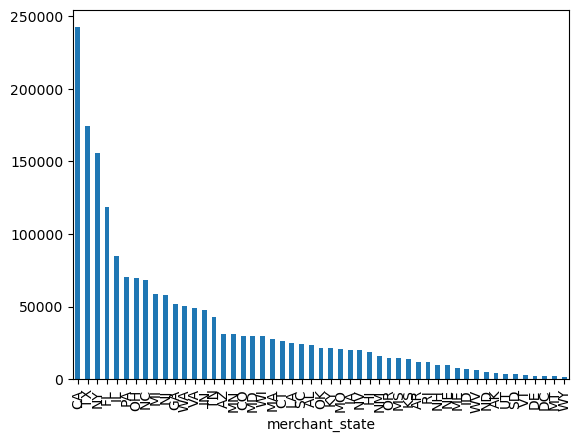

In [60]:
a=df3.groupby('merchant_state')['amount'].sum().sort_values(ascending=False)
print(a)
a.plot(kind='bar')

     merchant_state      merchant_city    amount
0                AK          Anchorage   3020.63
46               AL             Mobile   3457.21
106              AR  North Little Rock   2172.20
152              AZ             Tucson   9539.53
341              CA            Oakland  16378.42
481              CO             Aurora   4425.88
566              CT            Shelton   2363.63
579              DC         Washington   2154.49
581              DE             Newark    902.59
671              FL            Orlando  14217.33
718              GA            Atlanta  13994.05
830              HI            Waianae   7634.78
864              IA           Hawarden   2600.01
921              ID         Twin Falls   1697.76
953              IL            Chicago   9671.36
1157             IN       Indianapolis  12060.22
1252             KS            Wichita   4130.80
1286             KY         Louisville   6922.71
1374             LA         Shreveport   3221.79
1383             MA 

<Axes: xlabel='merchant_city'>

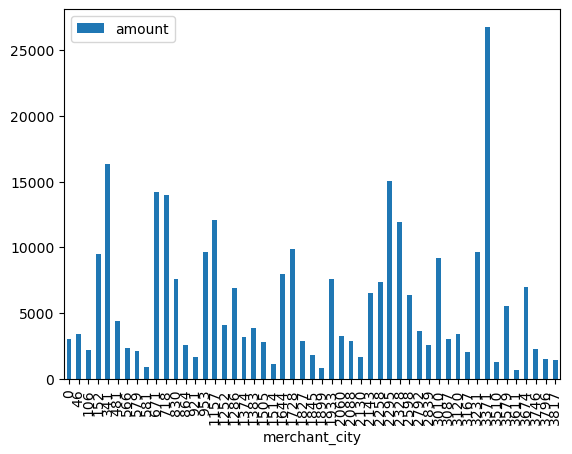

In [61]:
a=df3.groupby(['merchant_state','merchant_city'])['amount'].sum().reset_index().sort_values(['merchant_state','amount'],ascending=[True,False])
print(a.groupby('merchant_state').head(1))
a.groupby('merchant_state').head(1).plot(kind='bar',xlabel='merchant_city')

In [74]:
a=df3.groupby(['merchant_state','mcc'])['amount'].sum()
a


merchant_state  mcc 
AK              3260    1234.77
                3780    3018.33
                4121      19.58
                5411      11.83
                5499      18.62
                         ...   
WY              6300     321.87
                7538     170.03
                8043      13.26
                8049      13.36
                8099      13.96
Name: amount, Length: 2073, dtype: float64

## Merging the user_data and card_data tables and performing exploratory data analysis

In [78]:
df=pd.merge(df1,df2,on='client_id',how='left')
df
# print(merdf)
# merdf['client_id'].nunique()

,client_id,current_age,retirement_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,age_group,card_id,card_brand,card_type,has_chip,credit_limit,acct_open_date
0,825,53,66,Female,29278,59696,127613,787,5,Middle-aged,4524,Visa,Debit,YES,24295,09/2002
1,825,53,66,Female,29278,59696,127613,787,5,Middle-aged,2731,Visa,Debit,YES,21968,04/2014
2,825,53,66,Female,29278,59696,127613,787,5,Middle-aged,3701,Visa,Debit,YES,46414,07/2003
3,825,53,66,Female,29278,59696,127613,787,5,Middle-aged,42,Visa,Credit,NO,12400,01/2003
4,825,53,66,Female,29278,59696,127613,787,5,Middle-aged,4659,Mastercard,Debit (Prepaid),YES,28,09/2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,185,47,67,Female,15175,30942,71066,779,3,Middle-aged,5361,Amex,Credit,YES,6900,11/2000
6142,185,47,67,Female,15175,30942,71066,779,3,Middle-aged,2711,Visa,Credit,YES,5700,04/2012
6143,1007,66,60,Male,25336,54654,27241,618,1,Senior,1305,Mastercard,Credit,NO,9200,02/2012
6144,1110,21,60,Female,32325,65909,181261,673,2,Young Adult,743,Mastercard,Debit,YES,28074,01/2020


In [80]:
#average credit limit by age group
a=df.groupby('age_group')['credit_limit'].mean()
print(a)

age_group
Young Adult    14026.701370
Adult          14145.218841
Middle-aged    14681.685595
Senior         14383.182182
Name: credit_limit, dtype: float64


C:\Users\nayan\AppData\Local\Temp\ipykernel_10060\1986490147.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a=df.groupby('age_group')['credit_limit'].mean()


In [84]:
# card brands preferred by gender
a=df.groupby(['gender','card_brand'])['client_id'].count()
print(a)

gender  card_brand
Female  Amex           221
        Discover       115
        Mastercard    1651
        Visa          1152
Male    Amex           181
        Discover        94
        Mastercard    1558
        Visa          1174
Name: client_id, dtype: int64


In [86]:
# credit score vs credit limit correlation
df[['credit_score','credit_limit']].corr()

,credit_score,credit_limit
credit_score,1.000000,0.047529
credit_limit,0.047529,1.000000


In [89]:
# How many cards per client
df.groupby('client_id')['card_brand'].count()

client_id
0       4
1       3
2       5
3       4
4       5
       ..
1995    4
1996    3
1997    7
1998    3
1999    2
Name: card_brand, Length: 2000, dtype: int64

In [90]:
# chip usage by card type
df.groupby('card_type')['has_chip'].value_counts()

card_type        has_chip
Credit           YES         1842
                 NO           215
Debit            YES         3141
                 NO           370
Debit (Prepaid)  YES          517
                 NO            61
Name: count, dtype: int64

## importing the 3 tables to the mysql database

In [93]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse

# Database credentials
username = "root"
password = "@Nayan2897"
host = "localhost"
port = 3306
database = "finance"  # Changed to finance

# URL-encode the password
encoded_password = urllib.parse.quote_plus(password)

# Create engine
engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}"
)

# ── Upload all 3 tables ──────────────────────────────────────

tables = {
    "user":        df1,          # your clients dataframe
    "card":        df2,          # your cards dataframe
    "transaction": df3           # your transactions dataframe
}


for table_name, df in tables.items():
    try:
        df.to_sql(table_name, engine, if_exists="replace", index=False)
        print(f"✅ '{table_name}' written successfully — {len(df)} rows")
    except Exception as e:
        print(f"Error writing '{table_name}':", e)

# ── Verify by reading back ───────────────────────────────────

for table_name in tables.keys():
    try:
        result = pd.read_sql(f"SELECT * FROM {table_name} LIMIT 3;", engine)
        print(f"\n--- {table_name} ---")
        print(result)
    except Exception as e:
        print(f"Error reading '{table_name}':", e)

✅ 'user' written successfully — 2000 rows
✅ 'card' written successfully — 6146 rows
✅ 'transaction' written successfully — 39765 rows

--- user ---
   client_id  current_age  retirement_age  gender  per_capita_income  \
0        825           53              66  Female              29278   
1       1746           53              68  Female              37891   
2       1718           81              67  Female              22681   

   yearly_income  total_debt  credit_score  num_credit_cards    age_group  
0          59696      127613           787                 5  Middle-aged  
1          77254      191349           701                 5  Middle-aged  
2          33483         196           698                 5       Senior  

--- card ---
   card_id  client_id card_brand card_type has_chip  credit_limit  \
0     4524        825       Visa     Debit      YES         24295   
1     2731        825       Visa     Debit      YES         21968   
2     3701        825       Visa     D